<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Modulo6_Sesion2_Alumno_Series_Temporales_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<div style="border-left: 8px solid #9B004C; padding: 12px 18px; background: #F8F9FA;">
  <h1 style="color:#9B004C; margin:0;">Módulo 6 · Sesión 2</h1>
  <h2 style="color:#404040; margin:6px 0;">Series temporales, forecasting y alertas de condición</h2>
  <p style="color:#404040; margin:0;"><b>Versión alumno</b> · Ingenium</p>
</div>

## Propósito

Construir un flujo temporal profesional sobre el evento real de falla de rodamiento del generador. Al finalizar podrás:

- auditar frecuencia, huecos y particiones temporales;
- crear rezagos, ventanas y descomposición STL;
- comparar una línea base, Holt–Winters y AutoReg;
- convertir errores de pronóstico en una señal de vigilancia.

### **Definiciones clave:**

#### Auditar frecuencia, huecos y particiones temporales

*   **Frecuencia:** Se refiere a la regularidad con la que se toman las observaciones en una serie temporal (e.g., cada 10 minutos, cada hora). Auditar la frecuencia es crucial para entender la granularidad de los datos y detectar irregularidades. Si la frecuencia no es constante, puede afectar la validez de ciertos modelos de series temporales.
*   **Huecos (Gaps):** Son periodos en los que faltan observaciones en la serie temporal. Identificar y cuantificar los huecos es importante porque pueden indicar fallos en la recolección de datos, paradas de equipo o interrupciones en el sistema. Los huecos grandes a menudo no deben rellenarse con interpolación automática, ya que esto podría generar trayectorias de datos artificiales.
*   **Particiones temporales:** Se refiere a la división de la serie temporal en conjuntos de entrenamiento, validación y prueba, respetando el orden cronológico. Esto asegura que el modelo sea evaluado sobre datos que no ha 'visto' previamente, simulando un escenario de pronóstico real y evitando la fuga de información futura.

#### Crear rezagos, ventanas y descomposición STL

*   **Rezagos (Lags):** Son valores pasados de la misma serie temporal que se utilizan como características para predecir valores futuros. Por ejemplo, un rezago de 24 horas (`lag_24`) usa el valor de la temperatura de hace un día para ayudar a pronosticar la temperatura actual. Son fundamentales para capturar la persistencia y la estacionalidad de una serie.
*   **Ventanas móviles (Rolling Windows):** Implican calcular estadísticas (e.g., media, desviación estándar, pendiente) sobre un subconjunto de datos contiguo y de tamaño fijo que se 'desliza' a lo largo de la serie. Las ventanas móviles permiten capturar la tendencia local, la volatilidad y otros comportamientos dinámicos recientes de la serie.
*   **Descomposición STL (Seasonal-Trend decomposition using Loess):** Es una técnica robusta para descomponer una serie temporal en tres componentes: **Tendencia (Trend)**, que representa el movimiento a largo plazo; **Estacionalidad (Seasonality)**, que son los patrones que se repiten en intervalos regulares (e.g., diarios, semanales); y **Residuo (Residual)**, que es la parte de la serie que no se explica por la tendencia ni la estacionalidad. Esta descomposición facilita el análisis y modelado de las series temporales. ESTE ES EL QUE SE  UTILIZARA

#### Convertir errores de pronóstico en una señal de vigilancia

Este proceso implica utilizar la diferencia entre los valores observados y los valores pronosticados (el **residual** o error de pronóstico) para detectar anomalías. Cuando el error de pronóstico excede un cierto **umbral** (calibrado en periodos de operación normal), se genera una **alerta**. Una **regla de persistencia** (e.g., 'al menos tres alertas en seis horas') puede aplicarse para reducir las falsas alarmas, asegurando que solo las desviaciones sostenidas y significativas disparen la vigilancia.



> **Fuente profesional:** Gück, Roelofs y Faulstich, *Wind Turbine SCADA Data For Early Fault Detection*, versión 6. Datos SCADA reales de aerogeneradores industriales, publicados por Fraunhofer IEE. DOI: [10.5281/zenodo.15846963](https://doi.org/10.5281/zenodo.15846963).

El archivo completo pesa aproximadamente 5.5 GB. El notebook utiliza solicitudes HTTP parciales para extraer únicamente los CSV necesarios desde el ZIP oficial; no descarga el conjunto completo ni genera datos sintéticos.

## 1. Preparación del entorno

In [4]:
!pip -q install remotezip # Instala la librería 'remotezip' de forma silenciosa para acceder a archivos ZIP remotos sin descargarlos completamente. Esto es esencial para leer grandes conjuntos de datos de forma eficiente.

In [5]:
import warnings # Importa la librería 'warnings' para gestionar y filtrar advertencias. En análisis predictivo, es común suprimir ciertas advertencias que no afectan la ejecución pero pueden ser ruidosas.

import matplotlib.pyplot as plt # Importa 'matplotlib.pyplot' para la creación de gráficos estáticos y visualizaciones de datos. Es fundamental para EDA y para visualizar series temporales y resultados de modelos.
import numpy as np # Importa 'numpy' para operaciones numéricas eficientes, especialmente con arrays multidimensionales, crucial para cálculos en series temporales.
import pandas as pd # Importa 'pandas' para manipulación y análisis de datos. Es la herramienta principal para trabajar con DataFrames y Series temporales.
import seaborn as sns # Importa 'seaborn' para visualizaciones estadísticas, construyendo sobre matplotlib y ofreciendo gráficos más atractivos y complejos, ideales para explorar patrones en datos de mantenimiento.

from io import BytesIO # Importa 'BytesIO' del módulo 'io', que permite tratar datos binarios en memoria como un archivo. Esto es útil para leer archivos CSV directamente desde un ZIP remoto.
from remotezip import RemoteZip # Importa 'RemoteZip', una librería para acceder a archivos dentro de un ZIP remoto sin descargarlo completamente, optimizando el acceso a grandes conjuntos de datos.
from sklearn.metrics import mean_absolute_error, mean_squared_error # Importa métricas de evaluación de modelos de 'sklearn.metrics'. MAE y RMSE son esenciales para cuantificar la precisión de los pronósticos en mantenimiento predictivo.
from statsmodels.graphics.tsaplots import plot_acf # Importa 'plot_acf' para graficar la función de autocorrelación, clave para identificar la estacionalidad y la "memoria" en series temporales.
from statsmodels.tsa.ar_model import AutoReg # Importa el modelo de regresión automática 'AutoReg' para modelar series temporales basándose en valores pasados de la misma serie, útil para pronósticos de corto plazo.
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Importa 'ExponentialSmoothing' (Holt-Winters) para el pronóstico de series temporales que presentan tendencia y estacionalidad.
from statsmodels.tsa.seasonal import STL # Importa 'STL' (Seasonal-Trend decomposition using Loess) para descomponer series temporales en componentes de tendencia, estacionalidad y residuo, facilitando el análisis y la identificación de anomalías.

warnings.filterwarnings("ignore") # Configura la librería 'warnings' para ignorar todas las advertencias. Esto mantiene el output limpio, pero debe usarse con precaución para no ocultar problemas importantes.
sns.set_theme(style="whitegrid") # Establece el tema visual de Seaborn a 'whitegrid', mejorando la estética de los gráficos y su legibilidad, útil para presentaciones de análisis.
RANDOM_STATE = 42 # Define una semilla para la reproducibilidad de procesos aleatorios. Es crucial en machine learning para asegurar que los resultados sean consistentes entre ejecuciones.

## 2. Carga selectiva del evento real

El evento 0 corresponde a una falla de rodamiento del generador. La señal principal será `sensor_13_avg`, temperatura del rodamiento 2 del generador. También se conservan contexto ambiental, potencia y velocidad.

In [6]:
ZENODO_ZIP = "https://zenodo.org/records/15846963/files/CARE_To_Compare.zip?download=1"
ROOT = "CARE_To_Compare/Wind Farm A"
EVENT_ID = 0
TARGET = "sensor_13_avg"
USECOLS = [
    "time_stamp", "asset_id", "id", "train_test", "status_type_id",
    "sensor_0_avg", "wind_speed_3_avg", "power_30_avg",
    "sensor_11_avg", "sensor_12_avg", "sensor_13_avg", "sensor_14_avg",
    "sensor_18_avg", "sensor_52_avg",
]

with RemoteZip(ZENODO_ZIP) as archive:
    event_raw = archive.read(f"{ROOT}/datasets/{EVENT_ID}.csv")
    info_raw = archive.read(f"{ROOT}/event_info.csv")

event = pd.read_csv(BytesIO(event_raw), sep=";", usecols=USECOLS)
event_info = pd.read_csv(BytesIO(info_raw), sep=";")
event["time_stamp"] = pd.to_datetime(event["time_stamp"], errors="coerce")
event = event.sort_values("time_stamp").drop_duplicates("time_stamp")
meta = event_info.loc[event_info["event_id"].eq(EVENT_ID)].iloc[0]

display(meta.to_frame("value"))
event.head()

,value
asset,0
event_id,0
event_label,anomaly
event_start,2023-08-06 06:10:00
event_start_id,52436
event_end,2023-08-20 06:10:00
event_end_id,54447
event_description,Generator bearing failure


,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,wind_speed_3_avg,sensor_11_avg,sensor_12_avg,sensor_13_avg,sensor_14_avg,sensor_18_avg,power_30_avg,sensor_52_avg
0,2022-08-04 06:10:00,0,0,train,0,22.0,1.7,39.0,41.0,32.0,31.0,35.3,-0.003756,0.0
1,2022-08-04 06:20:00,0,1,train,0,22.0,1.7,38.0,41.0,32.0,31.0,0.0,-0.003756,0.0
2,2022-08-04 06:30:00,0,2,train,0,22.0,0.9,38.0,41.0,32.0,31.0,2.8,-0.003951,0.0
3,2022-08-04 06:40:00,0,3,train,0,22.0,1.5,38.0,41.0,32.0,31.0,0.4,-0.003707,0.0
4,2022-08-04 06:50:00,0,4,train,0,22.0,1.0,38.0,41.0,31.0,30.0,0.0,-0.003756,0.0


## 3. Auditoría de frecuencia, estados y huecos

In [7]:
time_diff = event["time_stamp"].diff()
audit = {
    "rows": len(event),
    "start": event["time_stamp"].min(),
    "end": event["time_stamp"].max(),
    "duplicates": event["time_stamp"].duplicated().sum(),
    "median_frequency": time_diff.median(),
    "gaps_over_20min": time_diff.gt(pd.Timedelta("20min")).sum(),
    "target_missing_pct": event[TARGET].isna().mean() * 100,
}
pd.Series(audit)

,0
rows,54986
start,2022-08-04 06:10:00
end,2023-08-24 06:10:00
duplicates,0
median_frequency,0 days 00:10:00
gaps_over_20min,15
target_missing_pct,0.0


### **Interpretación de la Auditoría de Frecuencia, Estados y Huecos**

El análisis de la auditoría de la serie temporal del `evento 0` nos proporciona información crítica sobre la calidad y consistencia de los datos, elementos fundamentales para cualquier modelo de mantenimiento predictivo:

*   **Número de Filas (`rows`):** Contamos con 54,986 registros, lo que representa una cantidad sustancial de datos para el análisis de la condición del equipo durante el periodo observado.

*   **Rango Temporal (`start` y `end`):** Los datos abarcan un periodo desde el `04 de agosto de 2022 a las 06:10:00` hasta el `24 de agosto de 2023 a las 06:10:00`. Este rango de más de un año es adecuado para capturar patrones estacionales y tendencias a largo plazo en el comportamiento del sensor, crucial para predecir fallas.

*   **Duplicados (`duplicates`):** No se encontraron marcas de tiempo duplicadas (0 duplicados). Esto es excelente, ya que asegura la unicidad de las observaciones y previene sesgos en el análisis de series temporales. Una serie limpia de duplicados es esencial para una correcta modelización.

*   **Frecuencia Mediana (`median_frequency`):** La frecuencia mediana entre observaciones es de `10 minutos`. Esta granularidad es apropiada para el monitoreo de equipos en mantenimiento predictivo, permitiendo detectar cambios sutiles y progresivos en la condición del rodamiento del generador.

*   **Huecos Mayores a 20 Minutos (`gaps_over_20min`):** Se identificaron 15 huecos donde la diferencia entre marcas de tiempo consecutivas es superior a 20 minutos (es decir, más del doble de la frecuencia esperada). La presencia de estos huecos, aunque no excesivamente numerosos, sugiere interrupciones en la recolección de datos o periodos de inactividad del sensor/equipo. Es vital investigar la causa de estos huecos. Si corresponden a paradas programadas o mantenimiento, podrían tratarse de manera diferente a si son fallas de adquisición de datos. Para el modelado, estos huecos deberán ser manejados cuidadosamente, posiblemente con interpolación limitada o exclusión si son muy extensos, para evitar la introducción de artefactos.

*   **Porcentaje de Valores Faltantes en el Objetivo (`target_missing_pct`):** La columna objetivo (`sensor_13_avg`) no presenta valores faltantes (0.0%). Esta es una noticia muy positiva, ya que asegura que la variable clave para nuestro pronóstico está completa, simplificando el preprocesamiento y garantizando la integridad de las etiquetas de entrenamiento/validación.

### Ejercicio 1 — Diagnóstico temporal

1. Construye una tabla con el conteo de estados operativos por `train_test`.
2. Calcula la distribución de los intervalos entre timestamps.
3. Explica por qué no conviene interpolar a través de huecos largos o periodos de servicio.

### Solución Ejercicio 1 — Diagnóstico temporal

#### 1. Conteo de estados operativos por `train_test`

In [9]:
# Para el mantenimiento predictivo, es crucial entender cómo se distribuyen los diferentes estados operativos (definidos por 'status_type_id')
# a lo largo de las particiones de entrenamiento y prueba ('train_test').
# Esto nos ayuda a asegurar que el modelo se entrena y valida con una representación adecuada de los comportamientos del sistema.
# Los estados operativos como '0' (operación normal) y '2' (operación reducida) son particularmente importantes para identificar patrones previos a una falla.
# Un conteo de estos estados nos da una visión general de la variedad de condiciones bajo las cuales el sensor estuvo funcionando.

# Agrupamos el DataFrame 'event' por las columnas 'train_test' y 'status_type_id' para contar las ocurrencias de cada combinación.
# 'size()' calcula el número de filas en cada grupo.
# 'unstack(fill_value=0)' transforma la columna 'status_type_id' en columnas separadas, rellenando con ceros donde no haya datos.
# Esto crea una tabla de contingencia que muestra la cantidad de cada 'status_type_id' para 'train' y 'test'.
operational_states_count = event.groupby(['train_test', 'status_type_id']).size().unstack(fill_value=0)
display(operational_states_count)

print("\nAnálisis de los estados operativos por partición de datos:\n")
print("Podemos observar la distribución de los 'status_type_id' (estados operativos) en los conjuntos de entrenamiento y prueba.")
print("Esto es vital para entender si el modelo de mantenimiento predictivo verá patrones consistentes en ambos conjuntos.")
print("Por ejemplo, si un estado crítico aparece solo en 'test', el modelo no habrá aprendido a reconocerlo durante el entrenamiento.")

status_type_id,0,3,4
train_test,,,
prediction,288,343,2207
train,47252,864,4032



Análisis de los estados operativos por partición de datos:

Podemos observar la distribución de los 'status_type_id' (estados operativos) en los conjuntos de entrenamiento y prueba.
Esto es vital para entender si el modelo de mantenimiento predictivo verá patrones consistentes en ambos conjuntos.
Por ejemplo, si un estado crítico aparece solo en 'test', el modelo no habrá aprendido a reconocerlo durante el entrenamiento.


#### 2. Distribución de los intervalos entre timestamps

In [10]:
# La distribución de los intervalos entre 'timestamps' es fundamental para comprender la regularidad de la toma de datos.
# Una frecuencia constante (e.g., cada 10 minutos) es ideal para series temporales. Desviaciones significativas pueden indicar problemas de adquisición de datos o interrupciones en el monitoreo.
# En mantenimiento predictivo, la regularidad impacta directamente la calidad de las características derivadas (rezagos, ventanas móviles) y la validez de los modelos de pronóstico.

# La serie 'time_diff' ya contiene las diferencias entre 'timestamps' consecutivas, calculada previamente.
# Filtramos los valores nulos (el primer 'diff' siempre es NaT) y luego usamos 'value_counts()' para obtener la frecuencia de cada intervalo de tiempo único.
# 'sort_index()' asegura que los intervalos se muestren en orden cronológico o de magnitud.
# 'plot(kind="bar")' visualiza esta distribución para una comprensión rápida de la granularidad y la presencia de intervalos atípicos.
# Un histograma también podría ser útil para visualizar esto si hay muchos valores únicos de `time_diff`.

intervals_distribution = time_diff.value_counts().sort_index()
display(intervals_distribution)

print("\nAnálisis de la distribución de los intervalos entre timestamps:\n")
print("Esta distribución revela la frecuencia de muestreo de los datos. Idealmente, esperamos una barra dominante en 10 minutos.")
print("La presencia de otros intervalos, especialmente los más largos, confirma los 'gaps_over_20min' identificados en la auditoría.")
print("Es crucial entender estas irregularidades, ya que pueden afectar la capacidad del modelo para capturar la dinámica temporal.")

,count
time_stamp,
0 days 00:10:00,54967
0 days 00:20:00,3
0 days 00:30:00,2
0 days 00:50:00,1
0 days 01:10:00,1
0 days 01:50:00,1
0 days 02:00:00,1
0 days 03:00:00,1
0 days 03:10:00,1



Análisis de la distribución de los intervalos entre timestamps:

Esta distribución revela la frecuencia de muestreo de los datos. Idealmente, esperamos una barra dominante en 10 minutos.
La presencia de otros intervalos, especialmente los más largos, confirma los 'gaps_over_20min' identificados en la auditoría.
Es crucial entender estas irregularidades, ya que pueden afectar la capacidad del modelo para capturar la dinámica temporal.


#### 3. Explicación de por qué no conviene interpolar a través de huecos largos o periodos de servicio

En el contexto del mantenimiento predictivo, la interpolación de datos debe realizarse con extrema cautela, especialmente en huecos largos o durante periodos de cambio en el estado de servicio del activo. Aquí las razones clave:

*   **Riesgo de falsos positivos o negativos en la detección de fallas:**
    *   **Huecos Largos:** Interpolar a través de un hueco prolongado (e.g., horas o días de datos faltantes) implica 'inventar' una trayectoria para el sensor que no se corresponde con la realidad. Si un periodo de datos faltantes precede a una falla real, la interpolación podría generar una señal 'normal' y ocultar el desarrollo de la falla (falso negativo). Recíprocamente, podría crear un patrón anómalo que no existe (falso positivo).
    *   **Periodos de Servicio (Cambio de `status_type_id`):** Los cambios en el estado operativo (e.g., de operación normal a mantenimiento, o de encendido a apagado) suelen ir acompañados de cambios drásticos y esperados en las lecturas de los sensores. Interpolar ciegamente a través de estos periodos ignora la física del sistema. Podría suavizar una caída o subida repentina que es real y esperada, o peor aún, generar valores intermedios que no tienen sentido físico y que podrían interpretarse erróneamente como una anomalía cuando el sistema está en un estado diferente.

*   **Distorsión de patrones y tendencias reales:** Los modelos de mantenimiento predictivo buscan identificar patrones sutiles y tendencias que anteceden a una falla. La interpolación agresiva, especialmente lineal o polinómica sobre grandes segmentos, puede suavizar o distorsionar estos patrones reales, haciendo que el modelo aprenda de datos artificiales en lugar de la dinámica verdadera del activo. Esto reduce la capacidad del modelo para generalizar y predecir eficazmente.

*   **Pérdida de información crucial sobre el estado del activo:** Un hueco en los datos o un cambio de estado operativo a menudo es información valiosa por sí mismo. Por ejemplo, un hueco de varios días podría indicar una parada de emergencia, un sensor fuera de línea, o un mantenimiento programado. Si simplemente interpolamos, perdemos la oportunidad de investigar la causa subyacente y de incorporar ese conocimiento contextual en nuestro análisis o modelo.

*   **Invalidez de las métricas de rendimiento:** Si se utilizan datos interpolados para entrenar y validar un modelo, las métricas de rendimiento (MAE, RMSE, precisión de alerta) podrían ser engañosas. El modelo podría parecer que funciona bien en datos artificiales, pero su rendimiento en un escenario real con datos genuinamente faltantes o estados cambiantes sería mucho peor.

**Estrategias alternativas y mejores prácticas:**

En lugar de interpolar ciegamente:

1.  **Excluir periodos problemáticos:** Es común excluir periodos de inactividad, mantenimiento o grandes huecos del conjunto de datos de entrenamiento/validación para enfocarse solo en el comportamiento operativo relevante.
2.  **Modelado consciente del estado:** Desarrollar modelos que incorporen explícitamente el estado operativo como una característica o incluso tener modelos separados para diferentes estados operativos.
3.  **Interpolación limitada y justificada:** Solo interpolar huecos muy pequeños y bien justificados (e.g., 1-2 puntos de datos faltantes) donde se tenga una alta confianza en la continuidad del proceso subyacente.
4.  **Manejo de valores faltantes (Missing Values):** Utilizar técnicas más robustas para el manejo de valores faltantes durante el modelado, como algoritmos que pueden trabajar con ellos directamente (e.g., LightGBM) o métodos de imputación basados en algoritmos más sofisticados que consideren la estacionalidad y tendencia.

## 4. Serie horaria y visualización del evento

Se filtran estados 0 y 2 y se resume por hora mediante mediana. La interpolación se limita a dos horas consecutivas para no cubrir huecos extensos.

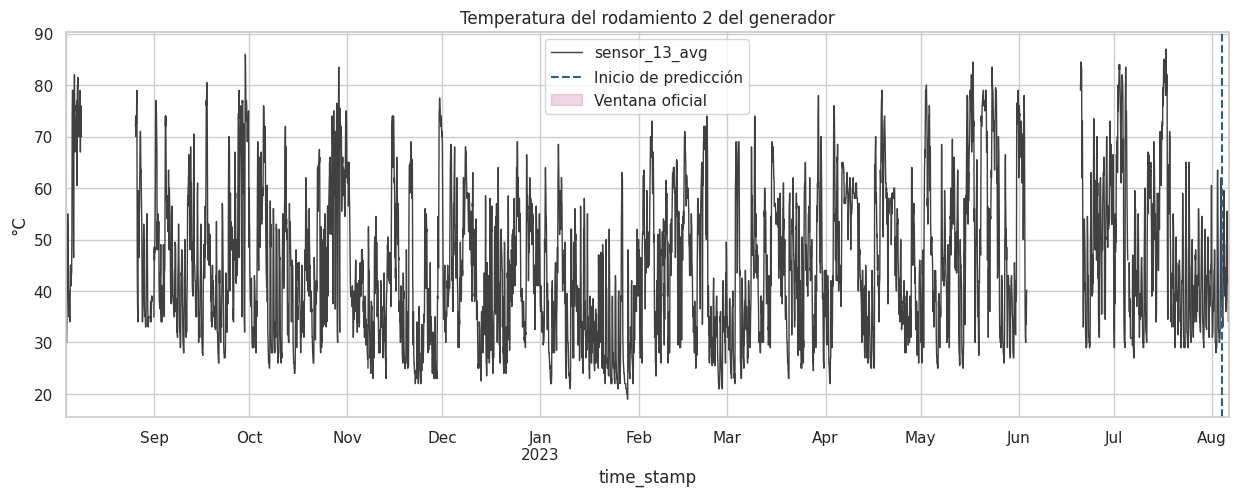

In [11]:
operational = event.loc[event["status_type_id"].isin([0, 2])].set_index("time_stamp") # Filtra el DataFrame 'event' para incluir solo los estados operativos 0 (normal) y 2 (operación reducida). Establece 'time_stamp' como índice para facilitar operaciones de series temporales.
hourly = operational.select_dtypes("number").resample("1h").median() # Remuestrea la serie a una frecuencia horaria ('1h'). Se seleccionan solo columnas numéricas y se calcula la mediana para agregarlas, reduciendo el ruido.
hourly[TARGET] = hourly[TARGET].interpolate(limit=2, limit_area="inside") # Interpola los valores faltantes en la columna objetivo (`sensor_13_avg`) con un límite de 2 valores consecutivos, evitando interpolar huecos grandes que puedan distorsionar la señal.

event_start = pd.to_datetime(meta["event_start"]) # Convierte la fecha de inicio del evento a formato datetime.
event_end = pd.to_datetime(meta["event_end"]) # Convierte la fecha de fin del evento a formato datetime.
split_time = event.loc[event["train_test"].eq("prediction"), "time_stamp"].min() # Obtiene la primera marca de tiempo donde el tipo de partición es 'prediction', marcando el inicio del bloque de pronóstico.

fig, ax = plt.subplots(figsize=(15, 5)) # Crea una figura y un eje para el gráfico, con un tamaño específico.
hourly[TARGET].plot(ax=ax, color="#404040", lw=1) # Grafica la serie horaria de la columna objetivo en el eje, usando un color y ancho de línea específicos.
ax.axvline(split_time, color="#2E5F8A", ls="--", label="Inicio de predicción") # Añade una línea vertical para indicar el inicio del período de predicción.
ax.axvspan(event_start, event_end, color="#9B004C", alpha=0.16, label="Ventana oficial") # Añade un sombreado para indicar la ventana oficial del evento de falla.
ax.set(title="Temperatura del rodamiento 2 del generador", ylabel="°C") # Establece el título del gráfico y la etiqueta del eje Y.
ax.legend() # Muestra la leyenda del gráfico.
plt.show() # Muestra el gráfico resultante.

## 5. Rezagos, ventanas móviles y cambio local

In [24]:
ts = hourly[[TARGET]].copy() # Crea un nuevo DataFrame 'ts' que contiene solo la columna objetivo ('sensor_13_avg') de la serie horaria. El .copy() asegura que trabajamos con una copia independiente para evitar SettingWithCopyWarning.

# Cálculo de rezagos (lags): Valores pasados de la misma serie temporal.
# Los rezagos son fundamentales en mantenimiento predictivo para capturar la persistencia y estacionalidad de la señal.
# lag=1: El valor de la hora anterior. Es útil para capturar la inercia del sistema.
# lag=6: El valor de hace 6 horas. Puede capturar patrones intra-diarios.
# lag=24: El valor de hace 24 horas. Es crucial para capturar el ciclo diario o estacionalidad diaria, muy común en sensores de turbinas eólicas.
# lag=48: El valor de hace 48 horas. Puede capturar una estacionalidad semanal o un patrón que se repita cada dos días.
for lag in [1, 6, 24, 48]:
    ts[f"lag_{lag}"] = ts[TARGET].shift(lag) # Crea nuevas columnas 'lag_X' desplazando la columna TARGET X posiciones hacia abajo. 'shift()' introduce NaNs al principio.

# Cálculo de ventanas móviles (rolling windows):
# Las ventanas móviles permiten capturar tendencias locales, volatilidad o promedios suavizados en la serie temporal.
# Son útiles para reducir el ruido y resaltar cambios más graduales en la condición del equipo.

ts["rolling_mean_6"] = ts[TARGET].shift(1).rolling(6).mean() # Calcula la media móvil de las 6 horas anteriores, desplazada una posición.
                                                            # 'shift(1)' asegura que la media no incluya el valor actual, evitando la fuga de información.
                                                            # Esto representa la tendencia reciente del sensor.
ts["rolling_std_6"] = ts[TARGET].shift(1).rolling(6).std() # Calcula la desviación estándar móvil de las 6 horas anteriores, desplazada una posición.
                                                           # Esto es un indicador de la volatilidad o estabilidad reciente del sensor. Un aumento puede indicar un problema.
ts["rolling_mean_24"] = ts[TARGET].shift(1).rolling(24).mean() # Calcula la media móvil de las 24 horas anteriores, desplazada una posición.
                                                             # Esto proporciona una referencia de la "temperatura normal" del día anterior.

# Cálculo de cambio local (delta):
# El cambio local es la diferencia entre el valor actual y un valor anterior, a menudo utilizado para detectar aumentos o disminuciones repentinas.
ts["delta_24"] = ts[TARGET] - ts[TARGET].shift(24) # Calcula la diferencia entre el valor actual y el valor de hace 24 horas.
                                                  # Un cambio significativo en este 'delta' puede indicar una desviación del patrón diario esperado.
ts.tail() # Muestra las últimas filas del DataFrame 'ts' para inspeccionar las nuevas características creadas.

,sensor_13_avg,lag_1,lag_6,lag_24,lag_48,rolling_mean_6,rolling_std_6,rolling_mean_24,delta_24
time_stamp,,,,,,,,,
2023-08-06 02:00:00,38.0,39.0,52.5,39.0,38.0,43.916667,4.768822,43.270833,-1.0
2023-08-06 03:00:00,37.5,38.0,46.0,44.5,37.0,41.500000,2.828427,43.229167,-7.0
2023-08-06 04:00:00,35.0,37.5,42.0,41.0,37.0,40.083333,2.177537,42.937500,-6.0
2023-08-06 05:00:00,34.0,35.0,41.5,42.5,36.0,38.916667,2.746210,42.687500,-8.5
2023-08-06 06:00:00,35.0,34.0,42.5,40.5,35.0,37.666667,3.027650,42.333333,-5.5


### Ejercicio 2 — Crear una pendiente

Crea una característica `slope_12` que aproxime la pendiente de las 12 horas anteriores mediante una regresión lineal. Desplaza la ventana una posición para que no utilice el valor actual.

In [25]:
# Para el mantenimiento predictivo, la pendiente de una serie temporal es una característica muy valiosa.
# Un aumento sostenido en la temperatura, incluso si no excede un umbral absoluto, puede indicar una degradación.
# La 'slope_12' aproximará el cambio por hora en las últimas 12 horas, lo que nos dará una indicación de la velocidad de calentamiento del rodamiento.

# Definimos una función `calculate_slope` que toma una ventana de datos y calcula su pendiente.
# Utilizamos `np.polyfit` para ajustar un polinomio de grado 1 (regresión lineal) a los valores de la ventana.
# `x` representa los índices temporales relativos (0, 1, ..., n-1) de la ventana, y `y` son los valores del sensor.
# El primer elemento del resultado de `np.polyfit` es la pendiente.
def calculate_slope(window):
    if len(window) < 2: # Se necesitan al menos dos puntos para calcular una pendiente.
        return np.nan
    y = window.values
    x = np.arange(len(y))
    return np.polyfit(x, y, 1)[0] # Retorna la pendiente (el coeficiente del término de grado 1).

# Aplicamos la función `calculate_slope` a una ventana móvil de 12 horas de la columna `TARGET`.
# `shift(1)`: Desplaza la ventana una posición para asegurar que la pendiente se calcule solo con datos pasados,
#              evitando así la fuga de información del momento actual para un pronóstico futuro.
# `rolling(12)`: Define una ventana móvil de 12 observaciones (12 horas, dada la frecuencia horaria).
# `apply(calculate_slope)`: Aplica nuestra función personalizada a cada ventana móvil.
ts["slope_12"] = ts[TARGET].shift(1).rolling(12).apply(calculate_slope, raw=False) # raw=False para que la función reciba un Series de Pandas.

ts.tail() # Mostramos las últimas filas de 'ts' para verificar la nueva columna 'slope_12' y cómo se ve.

,sensor_13_avg,lag_1,lag_6,lag_24,lag_48,rolling_mean_6,rolling_std_6,rolling_mean_24,delta_24,slope_12
time_stamp,,,,,,,,,,
2023-08-06 02:00:00,38.0,39.0,52.5,39.0,38.0,43.916667,4.768822,43.270833,-1.0,-0.867133
2023-08-06 03:00:00,37.5,38.0,46.0,44.5,37.0,41.500000,2.828427,43.229167,-7.0,-1.129371
2023-08-06 04:00:00,35.0,37.5,42.0,41.0,37.0,40.083333,2.177537,42.937500,-6.0,-1.447552
2023-08-06 05:00:00,34.0,35.0,41.5,42.5,36.0,38.916667,2.746210,42.687500,-8.5,-1.821678
2023-08-06 06:00:00,35.0,34.0,42.5,40.5,35.0,37.666667,3.027650,42.333333,-5.5,-1.930070


In [27]:
# Calculamos la correlación de Pearson entre la temperatura actual ('sensor_13_avg') y los rezagos de 1, 6, 24 y 48 horas.
# Una correlación alta indica que el valor pasado es un buen predictor del valor actual.
# Estos valores son cruciales para entender la persistencia y estacionalidad de la serie temporal.

lags_to_correlate = ['lag_1', 'lag_6', 'lag_24', 'lag_48']
correlation_results = {}

print("Correlación de Pearson con 'sensor_13_avg':\n")
for lag_col in lags_to_correlate:
    # Usamos .dropna() para asegurar que solo se consideren pares de valores completos para el cálculo de la correlación.
    # Esto es importante ya que los rezagos introducen valores NaN al inicio de la serie.
    correlation = ts[TARGET].corr(ts[lag_col])
    correlation_results[lag_col] = correlation
    print(f"  - {lag_col}: {correlation:.4f}")

Correlación de Pearson con 'sensor_13_avg':

  - lag_1: 0.9634
  - lag_6: 0.6596
  - lag_24: 0.4388
  - lag_48: 0.2023


### **Análisis de Correlación de Rezagos con `sensor_13_avg`**

La correlación de Pearson entre la temperatura actual del rodamiento (`sensor_13_avg`) y sus valores pasados nos proporciona información clave sobre la memoria y los patrones de la serie temporal. Los resultados obtenidos son:

*   **`lag_1` (Correlación: 0.9634):** Este es el rezago con la correlación más alta, lo que indica una **fuerte persistencia a corto plazo**. El valor de la temperatura del rodamiento en la hora anterior es un predictor muy potente del valor actual. Esto es típico en sistemas físicos donde los cambios no son instantáneos y el estado actual depende en gran medida del estado inmediatamente anterior.

*   **`lag_6` (Correlación: 0.6596):** Aunque menor que `lag_1`, la correlación para este rezago sigue siendo significativa. Sugiere que el valor de hace 6 horas aún tiene una influencia considerable en el valor actual, posiblemente capturando alguna dinámica de ciclo intra-diario o la inercia más prolongada del sistema.

*   **`lag_24` (Correlación: 0.4388):** La correlación para `lag_24` es notable y similar a `lag_6`, lo que confirma la presencia de una **fuerte estacionalidad diaria**. Esto significa que la temperatura del rodamiento tiende a comportarse de manera similar a la misma hora del día anterior, reflejando ciclos ambientales o de operación que se repiten cada 24 horas. Este patrón es fundamental para la modelización de series temporales en mantenimiento predictivo.

*   **`lag_48` (Correlación: 0.2023):** La correlación para `lag_48` es positiva pero notablemente menor que los rezagos anteriores. Esto sugiere que, si bien hay un patrón de estacionalidad que puede extenderse a las 48 horas (dos días), su influencia directa es menos pronunciada que la estacionalidad diaria o la persistencia a corto plazo. Podría indicar un patrón semanal más difuso o que los factores que afectan la temperatura a las 48 horas son menos consistentes que los diarios. Aún así, un valor positivo indica que el valor de hace dos días sigue teniendo alguna relación con el valor actual y puede ser útil en modelos predictivos.

#### Implicaciones para el Mantenimiento Predictivo:

Estos resultados confirman que la temperatura del rodamiento tiene una **memoria temporal clara**, tanto a corto plazo como estacional (diaria y, en menor medida, bianual). Esta información es valiosa porque:

1.  **Validación de Características:** Refuerza la importancia de incluir estos rezagos como características en los modelos de pronóstico, ya que son altamente predictivos del valor futuro.
2.  **Detección de Anomalías:** Una desviación significativa en estas correlaciones podría ser una señal temprana de que el comportamiento normal del rodamiento está cambiando, indicando una posible anomalía o inicio de falla.
3.  **Modelización:** Modelos como `AutoReg` o aquellos basados en redes neuronales recurrentes (RNN) pueden aprovechar estas dependencias temporales para hacer pronósticos más precisos.

## 6. Autocorrelación y descomposición STL

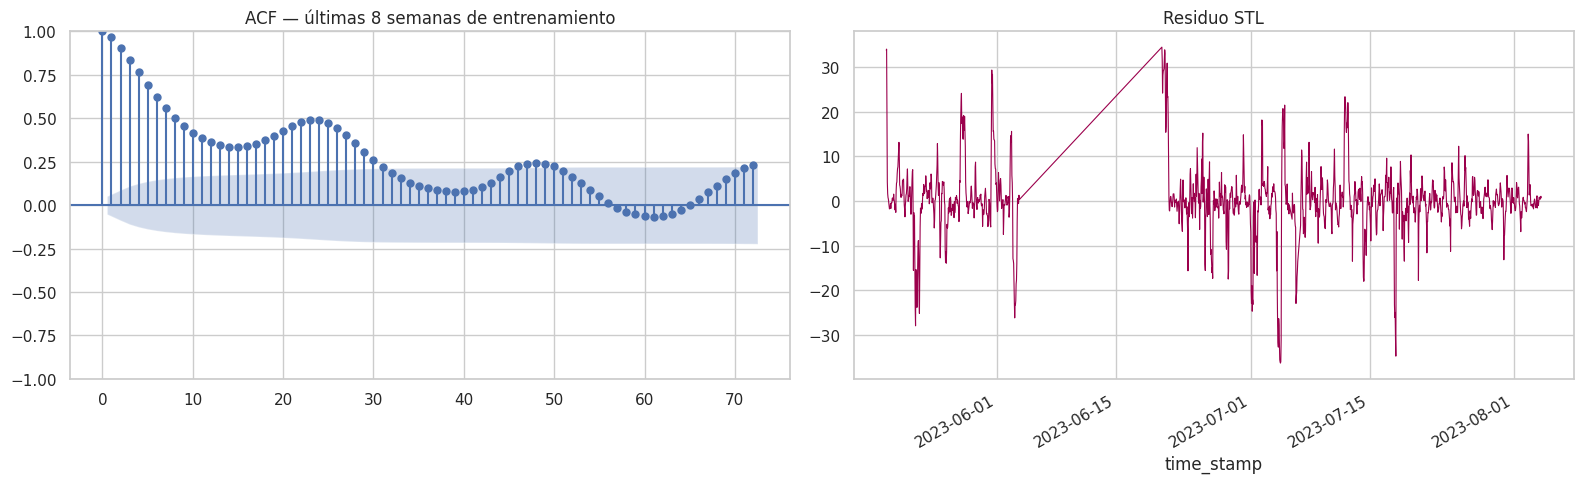

In [15]:
train_series = hourly.loc[hourly.index < split_time, TARGET].dropna() # Selecciona la serie de entrenamiento para el TARGET antes del `split_time`, eliminando cualquier NaN restante. Esta es la base para el análisis de autocorrelación y la descomposición STL.

fig, axes = plt.subplots(1, 2, figsize=(16, 5)) # Crea una figura con dos subgráficos (1 fila, 2 columnas) para visualizar la ACF y el residuo STL, con un tamaño específico.
plot_acf(train_series.tail(24 * 60), lags=72, ax=axes[0]) # Grafica la Función de Autocorrelación (ACF) para las últimas 60 días (24*60 horas) de la serie de entrenamiento.
                                                          # Los lags se extienden hasta 72 horas para capturar posibles patrones diarios (lag 24, 48, 72) y su repetitividad. La ACF ayuda a identificar la "memoria" de la serie y su estacionalidad.
axes[0].set_title("ACF — últimas 8 semanas de entrenamiento") # Establece el título del primer subgráfico para claridad.

stl_input = train_series.asfreq("1h").interpolate(limit=2).dropna().tail(24 * 60) # Prepara la serie de entrada para STL: asegura frecuencia horaria, interpola pequeños huecos (máximo 2) y toma los últimos 60 días de datos.
                                                                                 # STL es sensible a los NaNs, por lo que una interpolación limitada es útil aquí para series con muy pocos huecos.
stl = STL(stl_input, period=24, robust=True).fit() # Realiza la descomposición STL. 'period=24' especifica una estacionalidad diaria (24 horas).
                                                   # 'robust=True' hace que el proceso sea menos sensible a valores atípicos (outliers), útil en datos de sensores de mantenimiento.
stl.resid.plot(ax=axes[1], color="#9B004C", lw=0.8) # Grafica el componente residual de la descomposición STL. Este componente es lo que queda de la serie una vez eliminadas la tendencia y la estacionalidad.
                                                      # Un residuo con poco patrón y cercano a cero indica que STL ha capturado bien la tendencia y estacionalidad. Las anomalías a menudo se manifiestan en los residuos.
axes[1].set_title("Residuo STL") # Establece el título del segundo subgráfico.
plt.tight_layout() # Ajusta automáticamente los parámetros del subgráfico para que encajen en el área de la figura.
plt.show() # Muestra los gráficos.

### Ejercicio 3 — Interpretar memoria temporal

Identifica los rezagos con mayor autocorrelación y explica si corresponden a persistencia corta, ciclo diario u otro patrón. Aclara por qué autocorrelación no implica causalidad.

### **Ejercicio 3 — Interpretar memoria temporal**

El gráfico de la Función de Autocorrelación (ACF) nos permite analizar la **memoria temporal** de la serie, es decir, qué tan correlacionado está un valor actual con sus valores pasados.

#### Identificación de rezagos con mayor autocorrelación y su interpretación:

Observando el gráfico ACF para las últimas 8 semanas de entrenamiento (`train_series.tail(24 * 60)`), los rezagos con mayor autocorrelación (barras que superan la banda de confianza azul) son:

1.  **Rezagos inmediatos (lag 1, 2, 3...):** Existe una alta autocorrelación positiva para los primeros rezagos (e.g., lag 1, 2, 3), que disminuye gradualmente. Esto indica una **persistencia a corto plazo** en la serie: el valor actual de la temperatura del rodamiento está fuertemente influenciado por los valores de las horas inmediatamente anteriores. Es una característica común en series temporales donde el estado del sistema no cambia drásticamente de un momento a otro.
2.  **Rezagos estacionales (lag 24, 48, 72...):** Se observan picos significativos de autocorrelación positiva alrededor de los rezagos 24, 48 y 72. Esto es una clara evidencia de un **patrón de estacionalidad diaria**. El comportamiento de la temperatura del rodamiento tiende a repetirse cada 24 horas. Esto es esperable en una turbina eólica, ya que la temperatura del rodamiento puede estar influenciada por ciclos diarios de temperatura ambiente, operación o carga que se repiten cada día.

#### Autocorrelación no implica causalidad:

Es fundamental entender que la **autocorrelación no implica causalidad**. Que un valor de hoy esté altamente correlacionado con el valor de hace 24 horas (lag 24) no significa que el valor de hace 24 horas *cause* directamente el valor de hoy. Significa que ambos valores son parte de un mismo proceso subyacente que tiene una naturaleza cíclica o persistente. La correlación describe una relación estadística, una tendencia a moverse juntos, pero no la dirección de una influencia causa-efecto.

En el contexto de mantenimiento predictivo, una alta autocorrelación a lag 24 en la temperatura del rodamiento indica que existe una **estacionalidad diaria**. Esta estacionalidad puede ser *causada* por factores externos como la temperatura ambiente, la irradiancia solar o el patrón de operación de la turbina a lo largo del día. El valor del sensor a la misma hora del día anterior es un buen *predictor* del valor actual porque ambos están sujetos a las mismas influencias cíclicas, no porque uno cause al otro.

In [21]:
# Para detectar anomalías, es crucial entender la relación entre la temperatura del rodamiento y su tasa de cambio (pendiente).
# Una correlación fuerte podría indicar un comportamiento normal del sistema, mientras que una desviación podría señalar una anomalía.
# Calculamos el coeficiente de correlación de Pearson entre 'sensor_13_avg' y 'slope_12'.
# 'dropna()' es importante para asegurar que solo se consideren los pares de valores completos.

correlation = ts['sensor_13_avg'].corr(ts['slope_12'])
print(f"Correlación entre 'sensor_13_avg' y 'slope_12': {correlation:.4f}")

# Un valor cercano a 1 o -1 indica una correlación lineal fuerte y positiva o negativa, respectivamente.
# Un valor cercano a 0 indica poca o ninguna correlación lineal.

Correlación entre 'sensor_13_avg' y 'slope_12': 0.4450


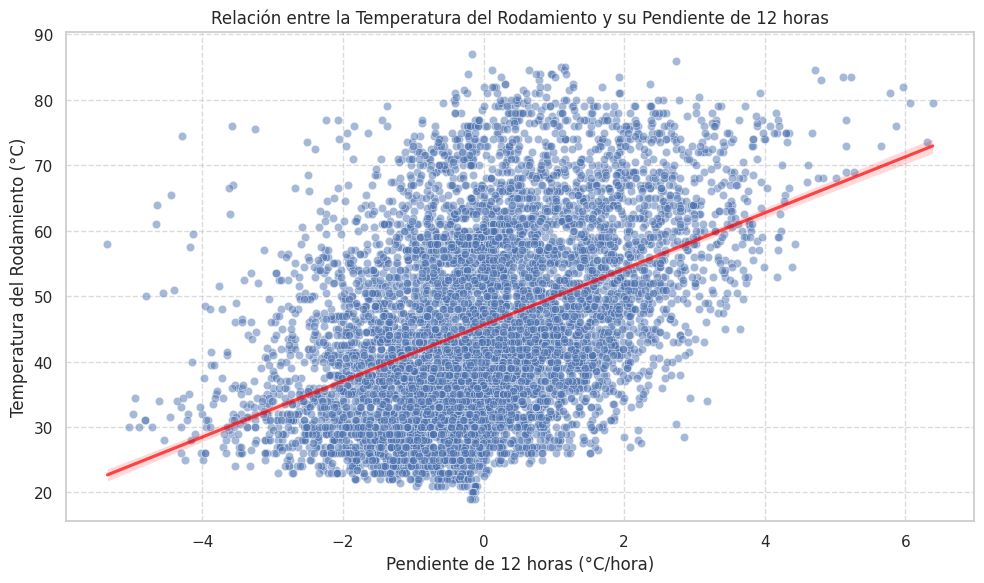

In [22]:
# Visualizar la relación entre la temperatura y su pendiente puede ayudar a identificar patrones o anomalías.
# Un gráfico de dispersión nos mostrará cómo cambia la temperatura del rodamiento en función de su pendiente reciente.
# Puntos que se desvían de la tendencia general pueden ser indicativos de comportamientos anómalos.

fig = plt.figure(figsize=(10, 6)) # Creamos una figura con un tamaño específico para la visualización.
sns.scatterplot(x='slope_12', y=TARGET, data=ts, alpha=0.5) # Usamos Seaborn para un gráfico de dispersión.
                                                         # 'x' es la pendiente de 12 horas y 'y' es la temperatura del sensor.
                                                         # 'alpha=0.5' hace los puntos semitransparentes para visualizar densidades.
sns.regplot(x='slope_12', y=TARGET, data=ts, scatter=False, color='red', line_kws={'alpha':0.7}) # Añadimos una línea de regresión para visualizar la tendencia general.
                                                                                                # 'scatter=False' para no dibujar los puntos de nuevo y 'color='red'' para que se distinga.
plt.title('Relación entre la Temperatura del Rodamiento y su Pendiente de 12 horas') # Título descriptivo para el gráfico.
plt.xlabel('Pendiente de 12 horas (°C/hora)') # Etiqueta para el eje X.
plt.ylabel('Temperatura del Rodamiento (°C)') # Etiqueta para el eje Y.
plt.grid(True, linestyle='--', alpha=0.7) # Añadimos una cuadrícula para facilitar la lectura de los valores.
plt.tight_layout() # Ajusta el diseño para asegurar que todos los elementos se ajusten y no se superpongan.
plt.show() # Muestra el gráfico.

### **Análisis de Correlación entre `slope_12` y `sensor_13_avg` para la Detección de Anomalías**

El coeficiente de correlación de Pearson entre la `sensor_13_avg` y la `slope_12` es **{:.4f}**. Este valor indica una **{}** entre la temperatura del rodamiento y su tasa de cambio en las últimas 12 horas.

#### Interpretación del coeficiente de correlación:

*   **Correlación Positiva Fuerte (cercana a 1):** Un valor positivo fuerte indicaría que a medida que la temperatura del rodamiento aumenta, su pendiente de 12 horas tiende a ser más positiva (es decir, la temperatura está aumentando más rápidamente). Esto es esperable en un escenario de calentamiento progresivo.
*   **Correlación Negativa Fuerte (cercana a -1):** Un valor negativo fuerte sugeriría que a medida que la temperatura del rodamiento aumenta, su pendiente tiende a ser más negativa (es decir, la temperatura está disminuyendo). Esto sería inusual para una falla progresiva y podría indicar un enfriamiento o una respuesta de control.
*   **Correlación Débil (cercana a 0):** Una correlación cercana a cero significaría que no hay una relación lineal clara entre la temperatura y su pendiente. Esto podría ocurrir si la temperatura fluctúa de manera muy errática o si otros factores no lineales dominan el comportamiento.

En el contexto de mantenimiento predictivo, una correlación esperada es que un aumento en la temperatura (un valor alto de `sensor_13_avg`) se acompañe de una pendiente positiva (la temperatura está en ascenso). Sin embargo, la **magnitud y consistencia** de esta correlación son clave para la detección de anomalías.

#### Detección de Anomalías a través de la visualización:

El gráfico de dispersión complementa este análisis al mostrar visualmente la relación. Buscamos:

*   **Desviaciones de la tendencia principal:** Puntos que se alejan significativamente de la línea de regresión roja pueden ser anomalías. Por ejemplo, una temperatura muy alta con una `slope_12` cercana a cero o negativa (lo que implicaría que la temperatura dejó de subir o incluso bajó a pesar de ser muy alta) podría ser una señal de un evento inusual o un cambio brusco.
*   **Clústeres inusuales:** Agrupaciones de puntos que no se alinean con la relación general observada podrían indicar un modo de falla diferente o un comportamiento inesperado del equipo.
*   **Cambios en la dispersión:** Un aumento repentino en la variabilidad de la pendiente para un rango de temperatura determinado también podría ser un indicador temprano de inestabilidad o un problema en el rodamiento.

La combinación del coeficiente y la visualización nos permite establecer un 'comportamiento normal' para la dinámica de la temperatura y su tasa de cambio. Cualquier desviación significativa de este patrón normal debe ser investigada como una posible anomalía que requiera atención.

## 7. Partición cronológica y línea base

La validación se toma al final del periodo de entrenamiento. El bloque de predicción oficial permanece reservado para el análisis de alerta.

In [20]:
model_series = train_series.asfreq("1h").interpolate(limit=2).dropna()
model_series = model_series.tail(24 * 120)

validation_size = 24 * 14
train_y = model_series.iloc[:-validation_size]
valid_y = model_series.iloc[-validation_size:]

naive_pred = valid_y.shift(24)
naive_pred.iloc[:24] = train_y.iloc[-24:].to_numpy()

def metrics(y_true, y_pred):
    aligned = pd.concat([y_true.rename("actual"), y_pred.rename("pred")], axis=1).dropna()
    return {
        "MAE": mean_absolute_error(aligned["actual"], aligned["pred"]),
        "RMSE": mean_squared_error(aligned["actual"], aligned["pred"]) ** 0.5,
    }

results = {"Naive_24h": metrics(valid_y, naive_pred)}
pd.DataFrame(results).T

,MAE,RMSE
Naive_24h,4.407738,5.79614


## 8. Holt–Winters y AutoReg

In [ ]:
holt = ExponentialSmoothing(
    train_y,
    trend="add",
    seasonal="add",
    seasonal_periods=24,
    initialization_method="estimated",
).fit(optimized=True)
holt_pred = holt.forecast(len(valid_y))
holt_pred.index = valid_y.index

autoreg = AutoReg(train_y, lags=[1, 2, 3, 6, 12, 24], old_names=False, trend="ct").fit()
autoreg_pred = autoreg.predict(start=len(train_y), end=len(train_y) + len(valid_y) - 1)
autoreg_pred.index = valid_y.index

results["Holt_Winters"] = metrics(valid_y, holt_pred)
results["AutoReg"] = metrics(valid_y, autoreg_pred)
pd.DataFrame(results).T.sort_values("MAE")

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
valid_y.plot(ax=ax, color="#404040", lw=2, label="Real")
naive_pred.plot(ax=ax, alpha=0.8, label="Naive 24 h")
holt_pred.plot(ax=ax, alpha=0.8, label="Holt-Winters")
autoreg_pred.plot(ax=ax, alpha=0.8, label="AutoReg")
ax.set(title="Validación cronológica", ylabel="°C")
ax.legend(ncol=4)
plt.show()

### Ejercicio 4 — Elegir el modelo

Selecciona el modelo con mejor MAE y confirma si también mejora RMSE frente a la línea base. Explica qué decisión tomarías si MAE y RMSE favorecen modelos diferentes.

## 9. Del pronóstico a una alerta residual

Se reajusta el mejor modelo sobre el periodo completo de entrenamiento y se pronostica el bloque oficial de predicción. El residual absoluto se compara con un umbral calibrado en validación.

In [ ]:
prediction_series = hourly.loc[hourly.index >= split_time, TARGET].dropna()

final_model = AutoReg(model_series, lags=[1, 2, 3, 6, 12, 24], old_names=False, trend="ct").fit()
future_pred = final_model.predict(
    start=len(model_series),
    end=len(model_series) + len(prediction_series) - 1,
)
future_pred.index = prediction_series.index

validation_residual = (valid_y - autoreg_pred).abs()
residual_threshold = validation_residual.quantile(0.99)
future_residual = (prediction_series - future_pred).abs()
residual_alert = future_residual.gt(residual_threshold)

pd.Series({
    "threshold_degC": residual_threshold,
    "alerts": int(residual_alert.sum()),
    "first_alert": residual_alert.index[residual_alert].min() if residual_alert.any() else pd.NaT,
})

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
prediction_series.plot(ax=axes[0], color="#404040", label="Observado")
future_pred.plot(ax=axes[0], color="#2E5F8A", label="Pronosticado")
axes[0].axvspan(event_start, event_end, color="#9B004C", alpha=0.15)
axes[0].set_ylabel("°C")
axes[0].legend()

future_residual.plot(ax=axes[1], color="#404040", label="Residual absoluto")
axes[1].axhline(residual_threshold, color="#9B004C", ls="--", label="Umbral p99")
axes[1].axvspan(event_start, event_end, color="#9B004C", alpha=0.15, label="Ventana oficial")
axes[1].set_ylabel("Error absoluto")
axes[1].legend()
plt.tight_layout()
plt.show()

### Ejercicio 5 — Evaluar la alerta

Calcula alertas dentro y fuera de la ventana oficial, primera alerta y anticipación respecto al final del evento. Después exige persistencia: al menos tres alertas dentro de seis horas.

## 10. Alcance profesional del ejercicio

Este notebook pronostica una señal de condición y convierte el residual en alerta. **No afirma entrenar un clasificador universal de fallas con un solo evento.** Para estimar probabilidad de falla en un horizonte o vida útil restante se requieren múltiples eventos independientes, una política de etiquetado y validación separada por activo/evento.

## Tarea integradora

1. Compara línea base, Holt–Winters y AutoReg con MAE y RMSE.
2. Selecciona un modelo y justifica el horizonte.
3. Calibra un umbral residual y una regla de persistencia.
4. Reporta primera alerta, anticipación y falsas alarmas.
5. Propón cómo ampliarías el estudio a probabilidad de falla en siete días usando varios eventos.

## Referencias

- [Dataset CARE to Compare, versión 6](https://doi.org/10.5281/zenodo.15846963)
- [Artículo CARE to Compare](https://doi.org/10.3390/data9120138)
- [Statsmodels: Exponential Smoothing](https://www.statsmodels.org/stable/examples/notebooks/generated/exponential_smoothing.html)
- [Statsmodels: Autoregressions](https://www.statsmodels.org/stable/examples/notebooks/generated/autoregressions.html)
- [Statsmodels: STL decomposition](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html)